**CNN**

In [5]:
# 1. GEREKLİ KÜTÜPHANELERİN İÇE AKTARILMASI
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import numpy as np

# GPU kontrolü
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

Kullanılan Cihaz: cpu


In [6]:
# 2. SENTETİK SINIFLANDIRMA VERİ SETİNİN OLUŞTURULMASI
# İnternetten veri indirmemek için rastgele 3 kanallı (RGB) 32x32 görüntüler üretiyoruz.
class SyntheticClassificationDataset(Dataset):
    def __init__(self, num_samples=400):
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        # 3 kanal (RGB), 32x32 boyutunda rastgele piksel değerleri [-1, 1] arası
        x = torch.randn(3, 32, 32)
        # 0 ile 9 arasında rastgele bir sınıf etiketi
        y = torch.randint(0, 10, (1,)).item()
        return x, y

trainset = SyntheticClassificationDataset(num_samples=400)
trainloader = DataLoader(trainset, batch_size=32, shuffle=True)

testset = SyntheticClassificationDataset(num_samples=80)
testloader = DataLoader(testset, batch_size=32, shuffle=False)

classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


In [7]:
# 3. CNN MİMARİSİNİN TANIMLANMASI
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=16, kernel_size=3, padding=1)
        self.relu1 = nn.ReLU()
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2) # 32x32 -> 16x16

        self.conv2 = nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3, padding=1)
        self.relu2 = nn.ReLU() # 16x16 -> 8x8 (pool ile)

        self.fc1 = nn.Linear(32 * 8 * 8, 128)
        self.relu3 = nn.ReLU()
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(self.relu1(self.conv1(x)))
        x = self.pool(self.relu2(self.conv2(x)))
        x = x.view(-1, 32 * 8 * 8)
        x = self.relu3(self.fc1(x))
        x = self.fc2(x)
        return x

model = SimpleCNN().to(device)

In [8]:
# 4. KAYIP FONKSİYONU VE OPTİMİZASYON
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 5. MODELİN EĞİTİLMESİ
epochs = 3
for epoch in range(epochs):
    running_loss = 0.0
    for i, (inputs, labels) in enumerate(trainloader):
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
    print(f"Epoch {epoch + 1}/{epochs} | Ortalama Kayıp: {running_loss / len(trainloader):.4f}")

print("Eğitim Tamamlandı!")


Epoch 1/3 | Ortalama Kayıp: 2.3238
Epoch 2/3 | Ortalama Kayıp: 2.2989
Epoch 3/3 | Ortalama Kayıp: 2.3081
Eğitim Tamamlandı!


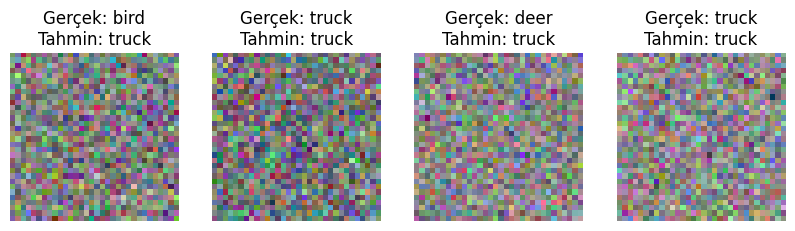

In [9]:

# 6. TAHMİN VE GÖRSELLEŞTİRME
dataiter = iter(testloader)
images, labels = next(dataiter)

outputs = model(images.to(device))
_, predicted = torch.max(outputs, 1)

# Görseller rastgele gürültüden ibaret olduğu için görselleştirme soyut görünecektir.
fig, axes = plt.subplots(1, 4, figsize=(10, 3))
for idx in range(4):
    img = images[idx]
    # Görseli [0, 1] aralığına normalize edip çizdiriyoruz
    npimg = ((img - img.min()) / (img.max() - img.min())).numpy()
    axes[idx].imshow(np.transpose(npimg, (1, 2, 0)))
    axes[idx].set_title(f"Gerçek: {classes[labels[idx]]}\nTahmin: {classes[predicted[idx]]}")
    axes[idx].axis('off')
plt.show()

**U-NET**


Kullanılan Cihaz: cpu
Epoch 1/3 | Kayıp: 0.4354
Epoch 2/3 | Kayıp: 0.3369
Epoch 3/3 | Kayıp: 0.2801


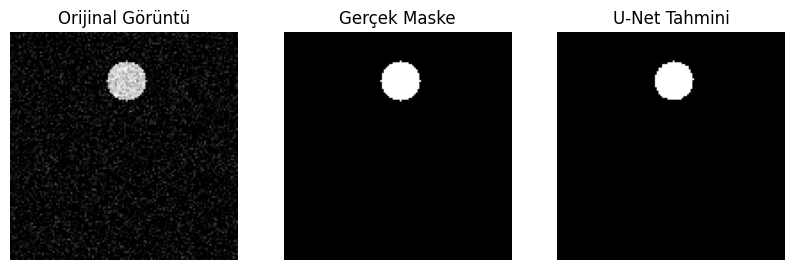

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import cv2

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

class SyntheticSegmentationDataset(Dataset):
    def __init__(self, num_samples=100):
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img = np.zeros((128, 128, 1), dtype=np.float32)
        mask = np.zeros((128, 128, 1), dtype=np.float32)

        cx = np.random.randint(20, 108)
        cy = np.random.randint(20, 108)
        r = np.random.randint(10, 30)

        cv2.circle(img, (cx, cy), r, 0.8, -1)
        img += np.random.normal(0, 0.1, img.shape)
        img = np.clip(img, 0.0, 1.0)

        cv2.circle(mask, (cx, cy), r, 1.0, -1)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()
        mask_tensor = torch.from_numpy(mask).permute(2, 0, 1).float()

        return img_tensor, mask_tensor

dataset = SyntheticSegmentationDataset(num_samples=100)
train_loader = DataLoader(dataset, batch_size=8, shuffle=True)

class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class SimpleUNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.inc = DoubleConv(1, 16)
        self.pool1 = nn.MaxPool2d(2)
        self.down1 = DoubleConv(16, 32)
        self.pool2 = nn.MaxPool2d(2)

        self.bottle = DoubleConv(32, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec1 = DoubleConv(64, 32)
        self.up2 = nn.ConvTranspose2d(32, 16, 2, stride=2)
        self.dec2 = DoubleConv(32, 16)

        self.outc = nn.Conv2d(16, 1, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.pool1(x1)
        x3 = self.down1(x2)
        x4 = self.pool2(x3)

        x_bottle = self.bottle(x4)

        u1 = self.up1(x_bottle)
        concat1 = torch.cat([x3, u1], dim=1)
        d1 = self.dec1(concat1)

        u2 = self.up2(d1)
        concat2 = torch.cat([x1, u2], dim=1)
        d2 = self.dec2(concat2)

        logits = self.outc(d2)
        return self.sigmoid(logits)

model = SimpleUNet().to(device)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

epochs = 3
for epoch in range(epochs):
    epoch_loss = 0
    for imgs, masks in train_loader:
        imgs, masks = imgs.to(device), masks.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Kayıp: {epoch_loss/len(train_loader):.4f}")

# Test görseli tahmini
model.eval()
test_img, test_mask = dataset[0]
with torch.no_grad():
    pred_mask = model(test_img.unsqueeze(0).to(device)).cpu().squeeze(0)

fig, axes = plt.subplots(1, 3, figsize=(10, 5))
axes[0].imshow(test_img.squeeze(), cmap='gray')
axes[0].set_title("Orijinal Görüntü")
axes[1].imshow(test_mask.squeeze(), cmap='gray')
axes[1].set_title("Gerçek Maske")
axes[2].imshow(pred_mask.squeeze() > 0.5, cmap='gray')
axes[2].set_title("U-Net Tahmini")
for ax in axes: ax.axis('off')
plt.show()

**Mask R-CNN**


Kullanılan Cihaz: cpu
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 53.1MB/s]
/tmp/ipykernel_702/4203174966.py:34: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  masks = torch.as_tensor([mask], dtype=torch.uint8)


Mask R-CNN Başarıyla Başlatıldı. Kayıplar: {'loss_classifier': tensor(0.6666, grad_fn=<NllLossBackward0>), 'loss_box_reg': tensor(0.0337, grad_fn=<DivBackward0>), 'loss_mask': tensor(2.4314, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_objectness': tensor(0.7021, grad_fn=<BinaryCrossEntropyWithLogitsBackward0>), 'loss_rpn_box_reg': tensor(0.0018, grad_fn=<DivBackward0>)}


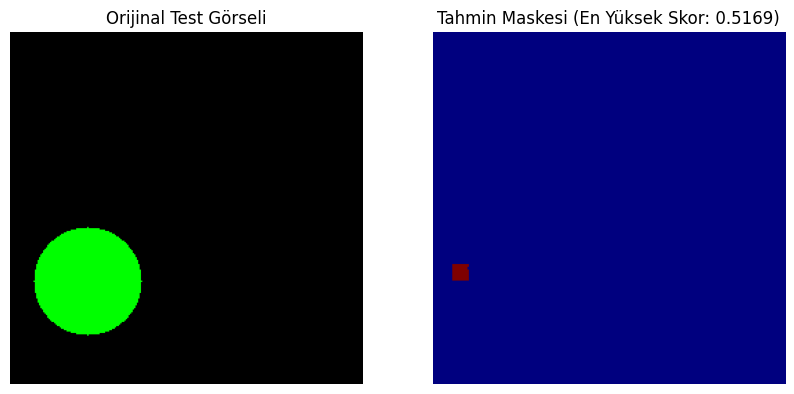

In [4]:
# 1. GEREKLİ KÜTÜPHANELERİN İÇE AKTARILMASI
import torch
import torchvision
from torchvision.models.detection.faster_rcnn import FastRCNNPredictor
from torchvision.models.detection.mask_rcnn import MaskRCNNPredictor
from torch.utils.data import Dataset, DataLoader
import numpy as np
import cv2
import matplotlib.pyplot as plt

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Kullanılan Cihaz: {device}")

# 2. SENTETİK VERİ SETİ
class MaskRCNNSyntheticDataset(Dataset):
    def __init__(self, num_samples=20):
        self.num_samples = num_samples

    def __len__(self):
        return self.num_samples

    def __getitem__(self, idx):
        img = np.zeros((256, 256, 3), dtype=np.float32)
        cx = np.random.randint(40, 216)
        cy = np.random.randint(40, 216)
        r = np.random.randint(20, 40)
        cv2.circle(img, (cx, cy), r, (0.0, 1.0, 0.0), -1)

        boxes = torch.as_tensor([[cx-r, cy-r, cx+r, cy+r]], dtype=torch.float32)
        labels = torch.ones((1,), dtype=torch.int64)

        mask = np.zeros((256, 256), dtype=np.uint8)
        cv2.circle(mask, (cx, cy), r, 1, -1)
        masks = torch.as_tensor([mask], dtype=torch.uint8)

        img_tensor = torch.from_numpy(img).permute(2, 0, 1).float()

        target = {}
        target["boxes"] = boxes
        target["labels"] = labels
        target["masks"] = masks

        return img_tensor, target

def collate_fn(batch):
    return tuple(zip(*batch))

dataset = MaskRCNNSyntheticDataset(num_samples=10)
data_loader = DataLoader(dataset, batch_size=2, shuffle=True, collate_fn=collate_fn)

# 3. MASK R-CNN MODELİNİN ÖZELLEŞTİRİLMESİ (İndirme Olmadan)
def get_custom_mask_rcnn(num_classes):
    # weights=None kullanarak internet indirmesini devre dışı bırakıyoruz.
    model = torchvision.models.detection.maskrcnn_resnet50_fpn(weights=None)

    in_features = model.roi_heads.box_predictor.cls_score.in_features
    model.roi_heads.box_predictor = FastRCNNPredictor(in_features, num_classes)

    in_features_mask = model.roi_heads.mask_predictor.conv5_mask.in_channels
    hidden_layer = 256
    model.roi_heads.mask_predictor = MaskRCNNPredictor(in_features_mask, hidden_layer, num_classes)

    return model

model = get_custom_mask_rcnn(num_classes=2).to(device)

# 4. TEK BİR EĞİTİM ADIMI (TEST ETMEK İÇİN)
model.train()
images, targets = next(iter(data_loader))
images = list(image.to(device) for image in images)
targets = [{k: v.to(device) for k, v in t.items()} for t in targets]

loss_dict = model(images, targets)
print(f"Mask R-CNN Başarıyla Başlatıldı. Kayıplar: {loss_dict}")

# 5. TEST (INFERENCE)
model.eval()
test_image, _ = dataset[0]
with torch.no_grad():
    prediction = model([test_image.to(device)])

pred_boxes = prediction[0]['boxes'].cpu().numpy()
pred_masks = prediction[0]['masks'].cpu().numpy()
pred_scores = prediction[0]['scores'].cpu().numpy()

# Çizim
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].imshow(test_image.permute(1, 2, 0).numpy())
ax[0].set_title("Orijinal Test Görseli")

# Rastgele ağırlıklarla çalıştığı için ilk başta doğru tahmin yapmayabilir,
# ancak kod yapısının çalıştığını doğrulamak için çıktıları kontrol ediyoruz.
if len(pred_scores) > 0:
    mask = pred_masks[0, 0] > 0.5
    ax[1].imshow(mask, cmap='jet')
    ax[1].set_title(f"Tahmin Maskesi (En Yüksek Skor: {pred_scores[0]:.4f})")
else:
    ax[1].imshow(np.zeros((256, 256)), cmap='gray')
    ax[1].set_title("Eşik değer üstünde nesne saptanamadı (Eğitilmemiş model)")

for a in ax: a.axis('off')
plt.show()